# Customer Churn Prediction — Telecom Industry

## Business Problem
A telecom company is losing a portion of its subscriber base every quarter. Acquiring a new customer costs significantly more than retaining an existing one, so the retention team wants to know **which customers are at the highest risk of cancelling their service** — and **why** — in time to act with a targeted offer (discount, plan change, proactive support call).

## Stakeholder / User Needs
- **Retention Marketing Team** needs a ranked list of at-risk customers each month, not just a yes/no label, so they can prioritize outreach.
- **Customer Success Managers** need to understand *which factors* (contract type, tenure, billing, services used) are driving churn, so retention offers target the right pain point instead of guessing.
- **Leadership** needs a measurable estimate of how many at-risk customers the model can correctly flag (recall) versus how many false alarms it creates (precision), since outreach has a real cost per customer contacted.

## Objective
Build and evaluate a classification model that predicts whether a customer will churn, using account, billing, and service-usage data, and surface the top business-actionable drivers of churn.

## Dataset
[IBM Telco Customer Churn dataset](https://github.com/IBM/telco-customer-churn-on-icp4d) — 7,043 customers, 21 attributes (demographics, account info, services subscribed, billing, and churn label).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, accuracy_score, precision_score, recall_score, f1_score)
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', None)


## 1. Load the Data

In [2]:
df = pd.read_csv('../data/telco_customer_churn.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Understanding

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Target variable balance
df['Churn'].value_counts(normalize=True).round(3) * 100


Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

## 3. Data Cleaning

`TotalCharges` is stored as text and has a few blank entries (customers with 0 tenure who haven't been billed yet). We convert it to numeric and impute those blanks with 0, since a brand-new customer genuinely has $0 total charges so far.


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing TotalCharges before fix: {df['TotalCharges'].isna().sum()}")

df['TotalCharges'] = df['TotalCharges'].fillna(0)

# customerID is just an identifier, not a predictive feature
df.drop(columns=['customerID'], inplace=True)

print(f"Missing values remaining: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")


Missing TotalCharges before fix: 11
Missing values remaining: 0
Duplicate rows: 22


## 4. Exploratory Data Analysis

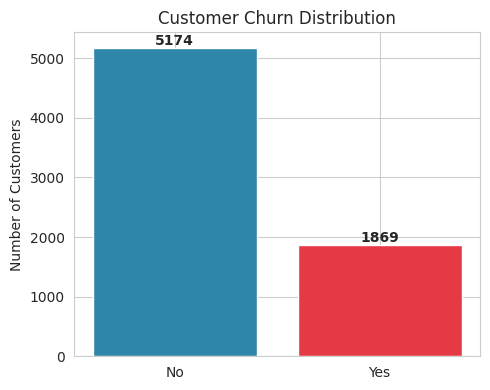

Overall churn rate: 26.5%


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts = df['Churn'].value_counts()
ax.bar(churn_counts.index, churn_counts.values, color=['#2E86AB', '#E63946'])
ax.set_title('Customer Churn Distribution')
ax.set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png', bbox_inches='tight')
plt.show()
print(f"Overall churn rate: {(df['Churn']=='Yes').mean():.1%}")


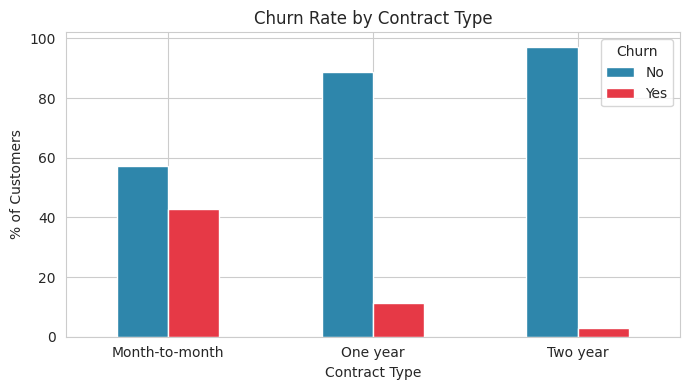

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', ax=ax, color=['#2E86AB', '#E63946'])
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('% of Customers')
ax.set_xlabel('Contract Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/02_churn_by_contract.png', bbox_inches='tight')
plt.show()


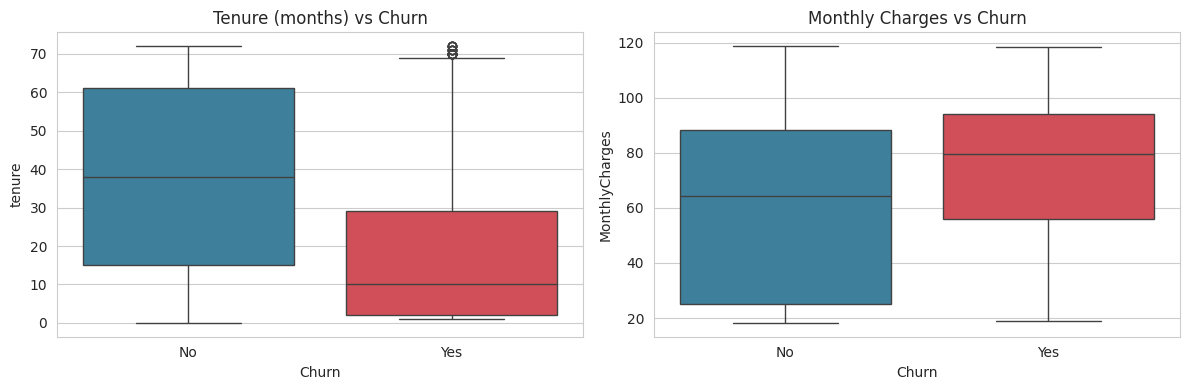

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette=['#2E86AB', '#E63946'])
axes[0].set_title('Tenure (months) vs Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette=['#2E86AB', '#E63946'])
axes[1].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.savefig('../outputs/03_tenure_charges_vs_churn.png', bbox_inches='tight')
plt.show()


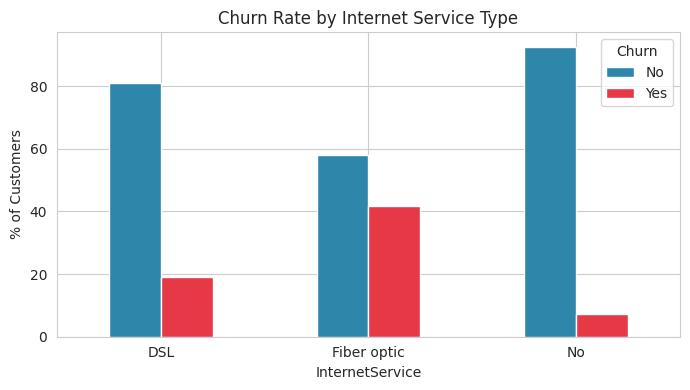

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', ax=ax, color=['#2E86AB', '#E63946'])
ax.set_title('Churn Rate by Internet Service Type')
ax.set_ylabel('% of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/04_churn_by_internet_service.png', bbox_inches='tight')
plt.show()


**Early EDA takeaways:**
- Customers on **month-to-month contracts** churn far more than those on one- or two-year contracts — contract length is a strong loyalty lever.
- Churned customers have **lower average tenure** — the first several months are the highest-risk window.
- **Fiber optic** internet customers churn more than DSL customers, which may point to a price or service-quality issue worth investigating with the network/product team.


## 5. Feature Engineering

Categorical columns are one-hot encoded, and numeric columns are scaled. We use an 80/20 train-test split, stratified on the target so both sets keep the same churn ratio.


In [10]:
df_model = df.copy()
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training rows: {X_train.shape[0]}  |  Test rows: {X_test.shape[0]}  |  Features: {X_train.shape[1]}")


Training rows: 5634  |  Test rows: 1409  |  Features: 30


## 6. Model Building

We train two models for comparison:
- **Logistic Regression** — a fast, interpretable baseline that's easy to explain to non-technical stakeholders.
- **Random Forest** — captures non-linear interactions between features and gives a feature-importance ranking for the business.

`class_weight='balanced'` is used on both models since churners are a minority class (~27%), and missing a real churner (false negative) is costlier to the business than a wasted retention call (false positive).


In [11]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)

print("Models trained.")


Models trained.


## 7. Model Evaluation

In [12]:
def evaluate(model, name, X_te, y_te):
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_te, preds):.3f}")
    print(f"Precision: {precision_score(y_te, preds):.3f}")
    print(f"Recall   : {recall_score(y_te, preds):.3f}")
    print(f"F1 Score : {f1_score(y_te, preds):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_te, proba):.3f}")
    print()
    return preds, proba

lr_preds, lr_proba = evaluate(log_reg, "Logistic Regression", X_test_scaled, y_test)
rf_preds, rf_proba = evaluate(rf, "Random Forest", X_test_scaled, y_test)


--- Logistic Regression ---
Accuracy : 0.738
Precision: 0.504
Recall   : 0.783
F1 Score : 0.614
ROC-AUC  : 0.842

--- Random Forest ---
Accuracy : 0.764
Precision: 0.538
Recall   : 0.783
F1 Score : 0.638
ROC-AUC  : 0.843



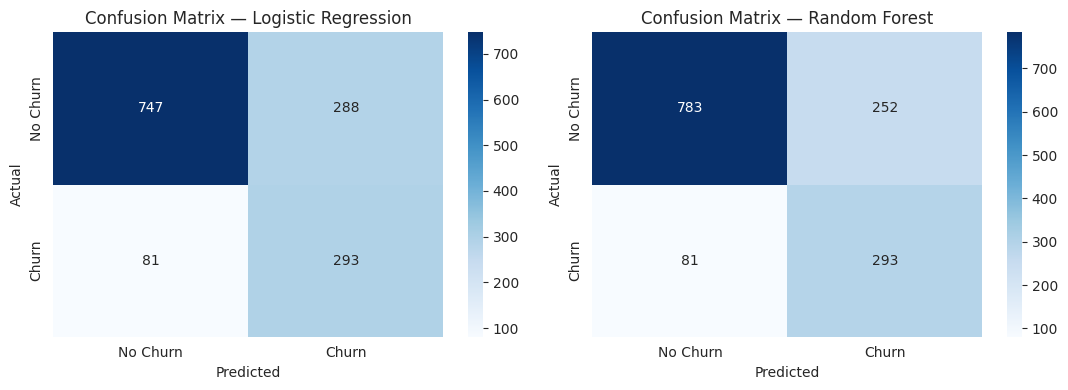

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (preds, name) in zip(axes, [(lr_preds, 'Logistic Regression'), (rf_preds, 'Random Forest')]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../outputs/05_confusion_matrices.png', bbox_inches='tight')
plt.show()


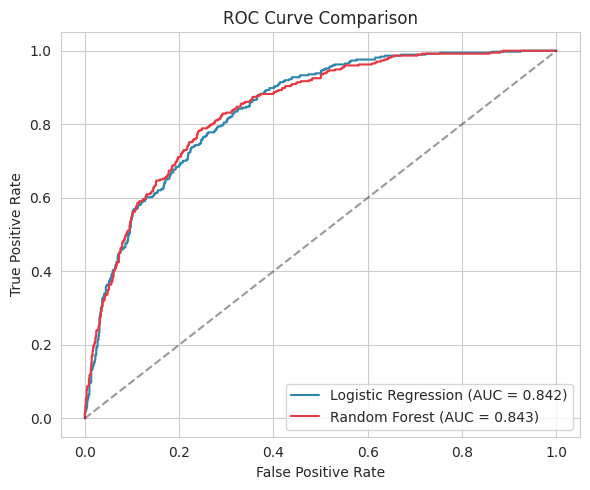

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
for proba, name, color in [(lr_proba, 'Logistic Regression', '#2E86AB'), (rf_proba, 'Random Forest', '#E63946')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/06_roc_curve.png', bbox_inches='tight')
plt.show()


## 8. Feature Importance (Business Drivers of Churn)

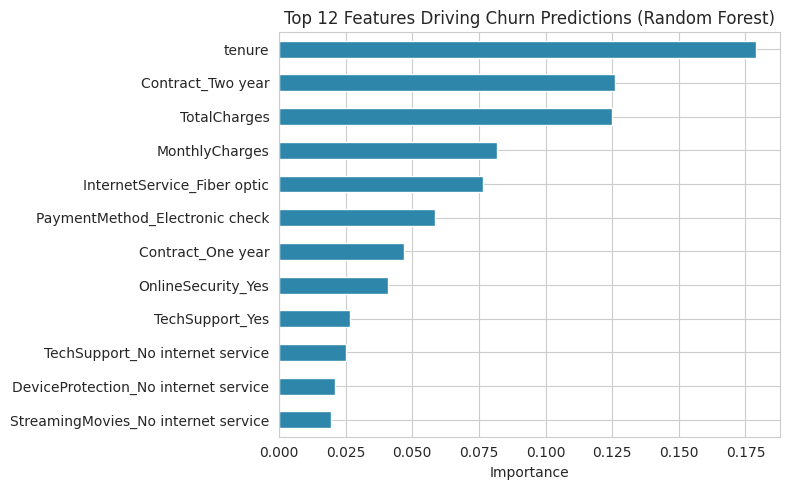

tenure                                  0.178995
Contract_Two year                       0.125895
TotalCharges                            0.124836
MonthlyCharges                          0.081757
InternetService_Fiber optic             0.076429
PaymentMethod_Electronic check          0.058401
Contract_One year                       0.047016
OnlineSecurity_Yes                      0.040804
TechSupport_Yes                         0.026667
TechSupport_No internet service         0.025029
DeviceProtection_No internet service    0.021165
StreamingMovies_No internet service     0.019373
dtype: float64

In [15]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
importances.sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 12 Features Driving Churn Predictions (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/07_feature_importance.png', bbox_inches='tight')
plt.show()

importances


## 9. Business Insights & Recommendations

1. **Contract type is the single biggest churn driver.** Month-to-month customers churn at a much higher rate than those on annual contracts — the retention team should prioritize converting month-to-month customers to longer commitments with a modest discount, rather than discounting everyone equally.
2. **Tenure matters most in the first year.** New customers are the highest-risk group; an onboarding check-in call/email in months 1–3 could reduce early churn.
3. **Fiber optic and higher monthly charges correlate with churn** — worth a closer look at whether pricing or service quality for that segment needs attention.
4. **Recall vs. precision trade-off:** with `class_weight='balanced'`, the model is tuned to catch more true churners (higher recall) at the cost of some false alarms — appropriate here, since a missed churner is far more expensive than one unnecessary retention call.

## 10. Save the Model


In [16]:
with open('../models/churn_model.pkl', 'wb') as f:
    pickle.dump({'model': rf, 'scaler': scaler, 'feature_columns': X_train.columns.tolist(),
                 'numeric_columns': num_cols}, f)
print("Model saved to ../models/churn_model.pkl")


Model saved to ../models/churn_model.pkl


## Limitations & Next Steps
- This dataset is a single snapshot in time; a production model would retrain monthly on rolling data and track drift.
- Class imbalance was handled with `class_weight='balanced'`; SMOTE oversampling or threshold tuning could be explored to further trade off precision/recall based on the retention team's call capacity.
- Hyperparameter tuning (GridSearchCV) and trying gradient boosting (XGBoost/LightGBM) are natural next steps to push performance further.
